In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def load_data():
    try :
        df = pd.read_csv("sys_data.csv")
        return df
    except FileNotFoundError :
        print("Make sure you have file in this directory")
        return None
    except Exception as e :
        print(f"Error : {str(e)}")
        return None
df = load_data()

In [3]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage
0,2026-01-15 15:50:01,4.9,28.3,39.5
1,2026-01-15 15:51:01,3.0,28.5,39.5
2,2026-01-15 15:52:01,5.8,28.4,39.5
3,2026-01-15 15:53:01,30.7,30.3,39.5
4,2026-01-15 15:54:01,5.8,27.7,39.5


In [4]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage
617,2026-01-18 17:24:02,8.4,46.3,42.8
618,2026-01-18 17:25:01,21.3,46.0,42.8
619,2026-01-18 17:26:01,15.6,46.1,42.8
620,2026-01-18 17:27:01,7.8,44.6,42.8
621,2026-01-18 17:28:01,7.8,43.3,42.8


In [5]:
df.isnull().sum()

timestamp       0
cpu_usage       0
memory_usage    0
disk_usage      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     622 non-null    object 
 1   cpu_usage     622 non-null    float64
 2   memory_usage  622 non-null    float64
 3   disk_usage    622 non-null    float64
dtypes: float64(3), object(1)
memory usage: 19.6+ KB


In [8]:
df.shape

(622, 4)

In [9]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

In [10]:
df.describe()

,cpu_usage,memory_usage,disk_usage
count,622.000000,622.000000,622.000000
mean,10.577170,41.250482,41.888746
std,11.448684,15.494162,1.352055
min,0.000000,9.000000,39.500000
25%,3.000000,27.425000,42.100000
50%,7.000000,44.550000,42.600000
75%,13.800000,56.675000,42.700000
max,98.300000,68.600000,44.100000


In [11]:
df["timestamp"].dtype

dtype('O')

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors = "coerce")

In [13]:
df["timestamp"].dtype

dtype('<M8[ns]')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 622 entries, 0 to 621
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     622 non-null    datetime64[ns]
 1   cpu_usage     622 non-null    float64       
 2   memory_usage  622 non-null    float64       
 3   disk_usage    622 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 19.6 KB


In [15]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage'], dtype='object')

In [16]:
def create_time_feature(df):
    df["year"] = df["timestamp"].dt.year
    df["month"] = df["timestamp"].dt.month
    df["day"] = df["timestamp"].dt.day
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["day_of_week"] = df["timestamp"].dt.day_name()
    df["month_name"] = df["timestamp"].dt.month_name()
    df["day_of_year"] = df["timestamp"].dt.dayofyear
    return df

df = create_time_feature(df)

In [17]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [18]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15


In [19]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year
617,2026-01-18 17:24:02,8.4,46.3,42.8,2026,1,18,17,24,Sunday,January,18
618,2026-01-18 17:25:01,21.3,46.0,42.8,2026,1,18,17,25,Sunday,January,18
619,2026-01-18 17:26:01,15.6,46.1,42.8,2026,1,18,17,26,Sunday,January,18
620,2026-01-18 17:27:01,7.8,44.6,42.8,2026,1,18,17,27,Sunday,January,18
621,2026-01-18 17:28:01,7.8,43.3,42.8,2026,1,18,17,28,Sunday,January,18


In [20]:
df.describe()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
count,622,622.000000,622.000000,622.000000,622.0,622.0,622.000000,622.000000,622.000000,622.000000
mean,2026-01-16 19:10:54.810289152,10.577170,41.250482,41.888746,2026.0,1.0,16.069132,17.027331,29.702572,16.069132
min,2026-01-15 15:50:01,0.000000,9.000000,39.500000,2026.0,1.0,15.000000,14.000000,0.000000,15.000000
25%,2026-01-15 20:00:16,3.000000,27.425000,42.100000,2026.0,1.0,15.000000,15.000000,13.000000,15.000000
50%,2026-01-16 16:21:31,7.000000,44.550000,42.600000,2026.0,1.0,16.000000,16.000000,30.000000,16.000000
75%,2026-01-17 15:05:46,13.800000,56.675000,42.700000,2026.0,1.0,17.000000,19.000000,46.000000,17.000000
max,2026-01-18 17:28:01,98.300000,68.600000,44.100000,2026.0,1.0,18.000000,22.000000,59.000000,18.000000
std,NaN,11.448684,15.494162,1.352055,0.0,0.0,0.893731,2.394484,17.987559,0.893731


In [21]:
df['timestamp'].min(), df['timestamp'].max()

(Timestamp('2026-01-15 15:50:01'), Timestamp('2026-01-18 17:28:01'))

In [22]:
df.corr(numeric_only=True)

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_year
cpu_usage,1.000000,0.097319,0.030083,NaN,NaN,-0.022162,0.015284,0.016640,-0.022162
memory_usage,0.097319,1.000000,0.159896,NaN,NaN,0.264930,-0.489112,-0.028104,0.264930
disk_usage,0.030083,0.159896,1.000000,NaN,NaN,0.713331,0.009794,-0.061709,0.713331
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,-0.022162,0.264930,0.713331,NaN,NaN,1.000000,-0.232645,-0.031073,1.000000
hour,0.015284,-0.489112,0.009794,NaN,NaN,-0.232645,1.000000,-0.162259,-0.232645
minute,0.016640,-0.028104,-0.061709,NaN,NaN,-0.031073,-0.162259,1.000000,-0.031073
day_of_year,-0.022162,0.264930,0.713331,NaN,NaN,1.000000,-0.232645,-0.031073,1.000000


In [23]:
df_numeric = df.select_dtypes(include=['int64', 'float64'])

In [24]:
df_numeric

,cpu_usage,memory_usage,disk_usage
0,4.9,28.3,39.5
1,3.0,28.5,39.5
2,5.8,28.4,39.5
3,30.7,30.3,39.5
4,5.8,27.7,39.5
...,...,...,...
617,8.4,46.3,42.8
618,21.3,46.0,42.8
619,15.6,46.1,42.8
620,7.8,44.6,42.8


In [25]:
corr = df_numeric.corr()
corr

,cpu_usage,memory_usage,disk_usage
cpu_usage,1.000000,0.097319,0.030083
memory_usage,0.097319,1.000000,0.159896
disk_usage,0.030083,0.159896,1.000000


In [26]:
df.columns

Index(['timestamp', 'cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month',
       'day', 'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year'],
      dtype='object')

In [27]:
df.groupby("hour")[["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
hour,,,
14,10.475000,42.127778,42.427778
15,10.655385,54.358462,42.444615
16,8.594697,39.412879,41.606061
17,11.030000,46.520000,40.696250
18,13.179412,45.047059,41.052941
19,15.744231,38.667308,41.267308
20,12.497368,25.847368,42.442105
21,6.546809,25.082979,42.600000
22,10.089189,25.148649,42.643243


In [28]:
df.groupby("day_of_week") [["cpu_usage", "memory_usage", "disk_usage"]].mean()

,cpu_usage,memory_usage,disk_usage
day_of_week,,,
Friday,9.602110,39.741350,42.583544
Saturday,11.447771,51.697452,42.738217
Sunday,8.971053,35.597368,42.800000
Thursday,11.395263,35.631053,40.137895


In [29]:
df[df['day_of_week'] == 'Saturday'].groupby('hour')['memory_usage'].mean()

hour
14    48.739394
15    59.755000
16    48.765217
18    51.212500
19    42.118182
20    18.400000
Name: memory_usage, dtype: float64

In [30]:
df.groupby(['day_of_week','hour'])[['cpu_usage','memory_usage']].mean()


cpu_usage  memory_usage
day_of_week hour                         
Friday      14     8.556410     36.533333
            15    11.391667     53.308333
            16    10.694444     49.740741
            21     6.546809     25.082979
            22    10.089189     25.148649
Saturday    14    12.742424     48.739394
            15    10.045000     59.755000
            16    12.039130     48.765217
            18    12.881250     51.212500
            19    12.304545     42.118182
            20     6.800000     18.400000
Sunday      16     0.888889     14.266667
            17    11.479310     42.217241
Thursday    15     9.900000     28.280000
            16     5.915217     27.532609
            17    10.774510     48.966667
            18    13.444444     39.566667
            19    18.266667     36.136667
            20    12.985714     26.485714

In [31]:
df.groupby('day')[['memory_usage']].mean()

,memory_usage
day,
15,35.631053
16,39.741350
17,51.697452
18,35.597368


In [32]:
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

In [33]:
df.head()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
0,2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False
1,2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False
2,2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False
3,2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False
4,2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False


In [34]:
df.tail()

,timestamp,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend
617,2026-01-18 17:24:02,8.4,46.3,42.8,2026,1,18,17,24,Sunday,January,18,True
618,2026-01-18 17:25:01,21.3,46.0,42.8,2026,1,18,17,25,Sunday,January,18,True
619,2026-01-18 17:26:01,15.6,46.1,42.8,2026,1,18,17,26,Sunday,January,18,True
620,2026-01-18 17:27:01,7.8,44.6,42.8,2026,1,18,17,27,Sunday,January,18,True
621,2026-01-18 17:28:01,7.8,43.3,42.8,2026,1,18,17,28,Sunday,January,18,True


In [35]:
df['cpu_roll_mean_5'] = df['cpu_usage'].rolling(window=5).mean()

In [36]:
df["cpu_roll_mean_5"]

0        NaN
1        NaN
2        NaN
3        NaN
4      10.04
       ...  
617    10.22
618    12.78
619    13.64
620    12.68
621    12.18
Name: cpu_roll_mean_5, Length: 622, dtype: float64

In [37]:
df['cpu_roll_std_5'] = df['cpu_usage'].rolling(window=5).std()

In [38]:
df["cpu_roll_std_5"]

0            NaN
1            NaN
2            NaN
3            NaN
4      11.605731
         ...    
617     1.810249
618     5.003699
619     5.054998
620     5.714630
621     6.073055
Name: cpu_roll_std_5, Length: 622, dtype: float64

In [40]:
df.set_index("timestamp", inplace=True)
df['cpu_roll_30min'] = df['cpu_usage'].rolling('30min').mean()

In [41]:
df["cpu_roll_30min"]

timestamp
2026-01-15 15:50:01     4.900000
2026-01-15 15:51:01     3.950000
2026-01-15 15:52:01     4.566667
2026-01-15 15:53:01    11.100000
2026-01-15 15:54:01    10.040000
                         ...    
2026-01-18 17:24:02     9.476667
2026-01-18 17:25:01    10.126667
2026-01-18 17:26:01    10.303226
2026-01-18 17:27:01    10.225000
2026-01-18 17:28:01    10.151515
Name: cpu_roll_30min, Length: 622, dtype: float64

In [42]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [43]:
df.head()

,cpu_usage,memory_usage,disk_usage,year,month,day,hour,minute,day_of_week,month_name,day_of_year,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,2026,1,15,15,50,Thursday,January,15,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,2026,1,15,15,51,Thursday,January,15,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,2026,1,15,15,52,Thursday,January,15,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,2026,1,15,15,53,Thursday,January,15,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,2026,1,15,15,54,Thursday,January,15,False,10.04,11.605731,10.040000


In [44]:
df.columns

Index(['cpu_usage', 'memory_usage', 'disk_usage', 'year', 'month', 'day',
       'hour', 'minute', 'day_of_week', 'month_name', 'day_of_year',
       'is_weekend', 'cpu_roll_mean_5', 'cpu_roll_std_5', 'cpu_roll_30min'],
      dtype='object')

In [45]:
df = df.drop(columns = ["year", "month", "day", "day_of_week", "month_name", "day_of_year"])

In [46]:
df.head()

,cpu_usage,memory_usage,disk_usage,hour,minute,is_weekend,cpu_roll_mean_5,cpu_roll_std_5,cpu_roll_30min
timestamp,,,,,,,,,
2026-01-15 15:50:01,4.9,28.3,39.5,15,50,False,NaN,NaN,4.900000
2026-01-15 15:51:01,3.0,28.5,39.5,15,51,False,NaN,NaN,3.950000
2026-01-15 15:52:01,5.8,28.4,39.5,15,52,False,NaN,NaN,4.566667
2026-01-15 15:53:01,30.7,30.3,39.5,15,53,False,NaN,NaN,11.100000
2026-01-15 15:54:01,5.8,27.7,39.5,15,54,False,10.04,11.605731,10.040000


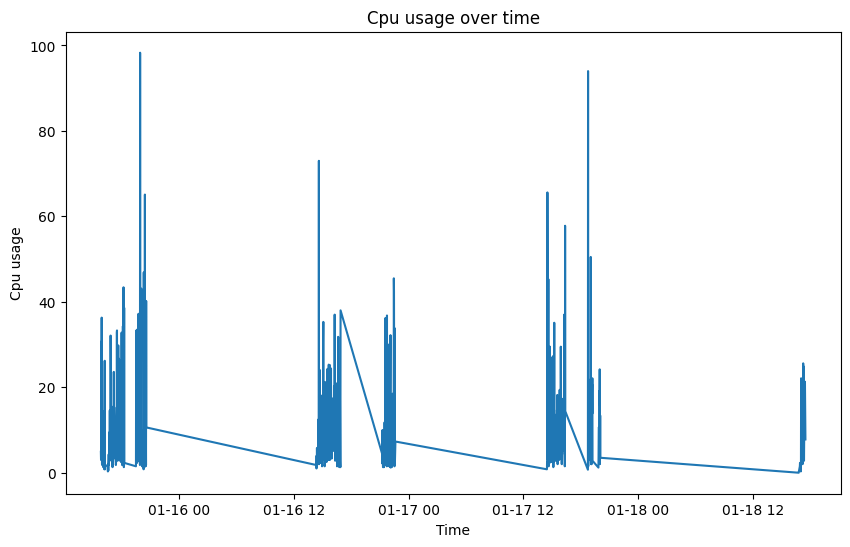

In [47]:
#plot cpu usage over time 
plt.figure(figsize = (10,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.xlabel("Time")
plt.ylabel("Cpu usage")
plt.title("Cpu usage over time")
plt.savefig("Cpu_usage_over_time_plot.png", dpi=300)
plt.show()

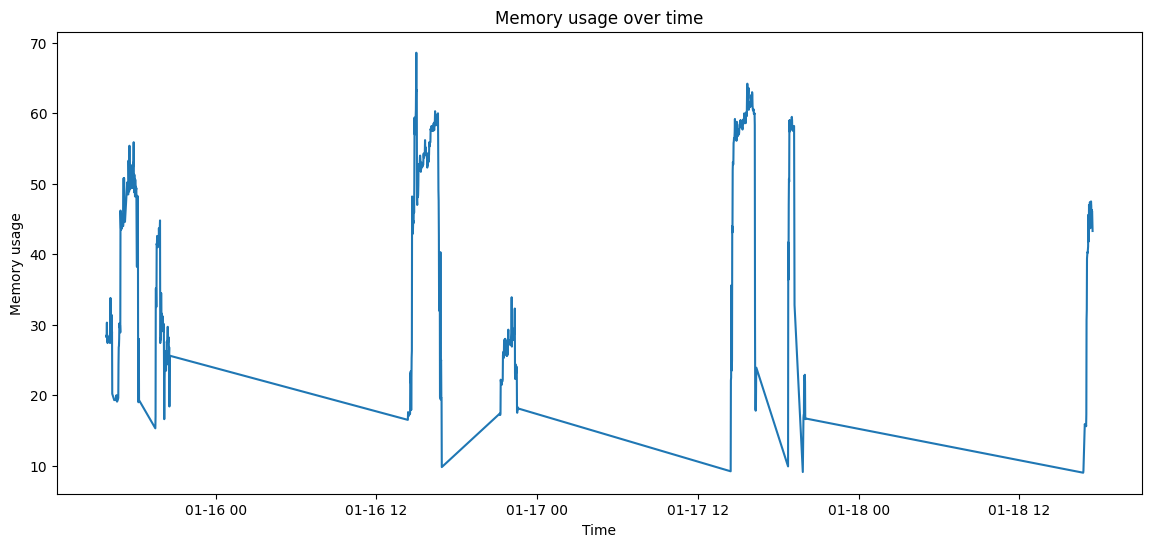

In [48]:
#plot memory usage overtime

plt.figure(figsize = (14,6))
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.xlabel("Time")
plt.ylabel("Memory usage")
plt.title("Memory usage over time")
plt.savefig("Memory_usage_over_time_plot.png")
plt.show()

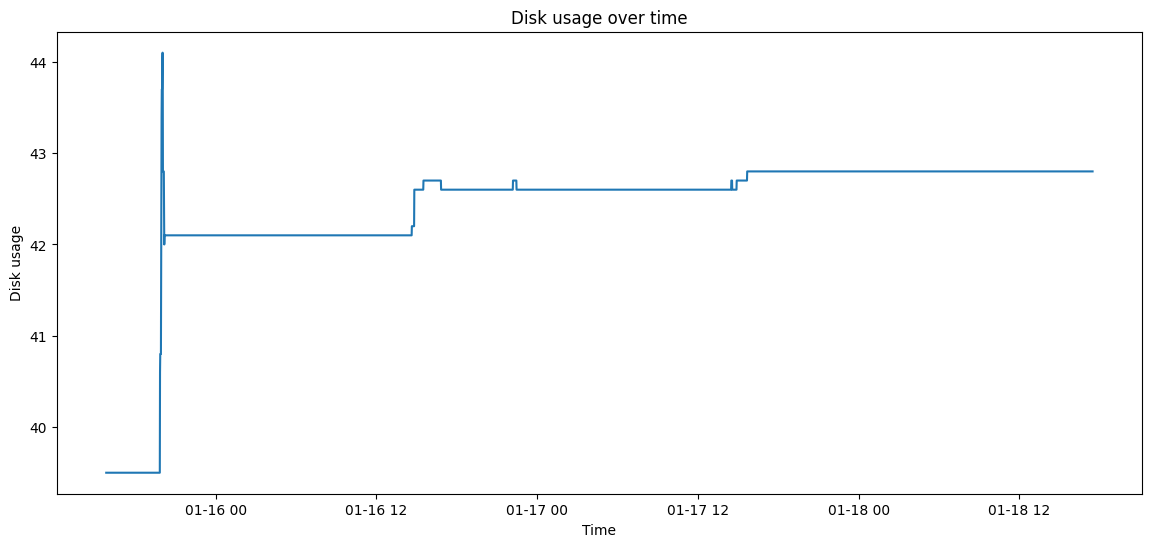

In [49]:
#plot disk usage over time 
plt.figure(figsize = (14,6))
plt.plot(df.index, df["disk_usage"], label= "Disk usage")
plt.xlabel("Time")
plt.ylabel("Disk usage")
plt.title("Disk usage over time")
plt.savefig("disk_usage_over_time_plot.png")
plt.show()

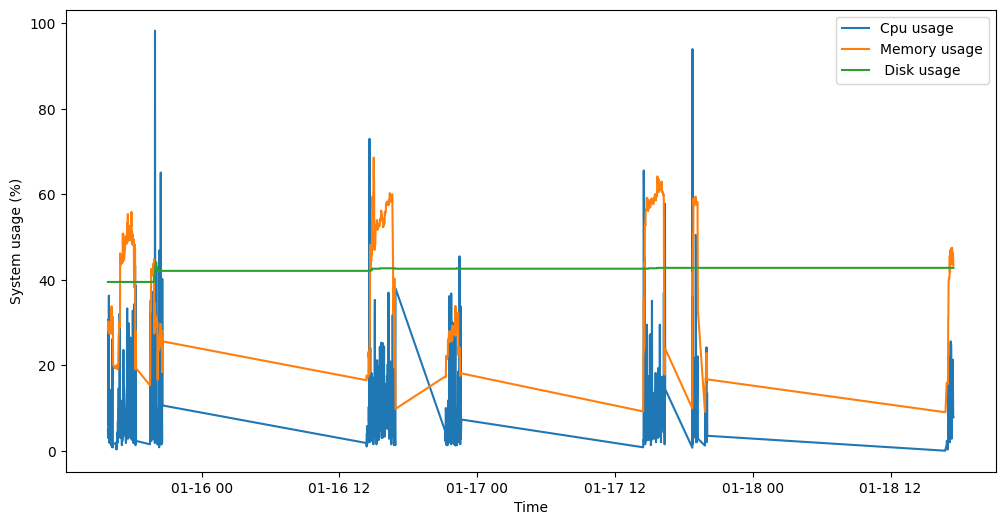

In [50]:
# plot system usage over time 
plt.figure(figsize = (12,6))
plt.plot(df.index, df["cpu_usage"], label = "Cpu usage")
plt.plot(df.index, df["memory_usage"], label = "Memory usage")
plt.plot(df.index, df["disk_usage"], label = " Disk usage")
plt.xlabel("Time")
plt.ylabel("System usage (%)")
plt.legend()
plt.savefig("system_usage_over_time_plot.png", dpi = 300)
plt.show()

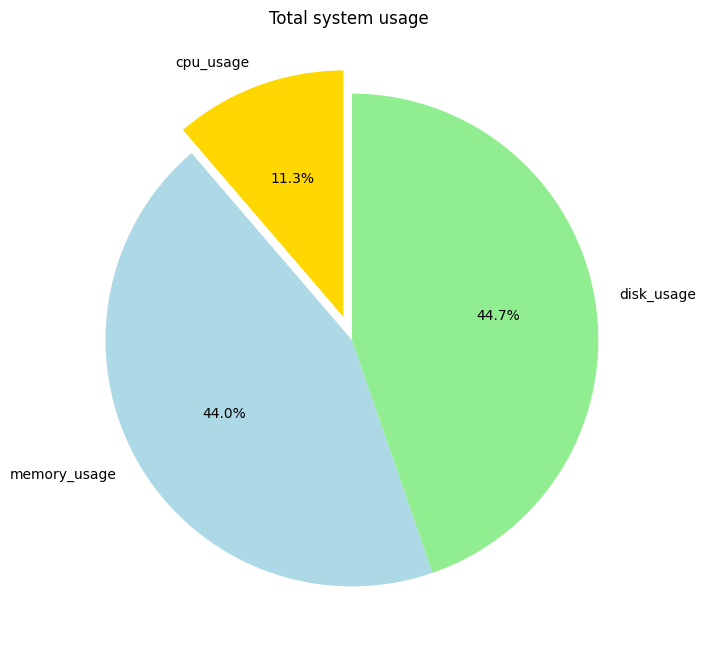

In [51]:
# pie chart plot of system usage 

usage_total = df[["cpu_usage", "memory_usage", "disk_usage"]].sum()

plt.figure(figsize = (8,8))
plt.pie(
    usage_total,
    labels = usage_total.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['gold', 'lightblue', 'lightgreen'],
    explode=(0.1,0,0)
)
plt.title("Total system usage ")
plt.savefig("Total_system_usage_piechart.png")
plt.show()

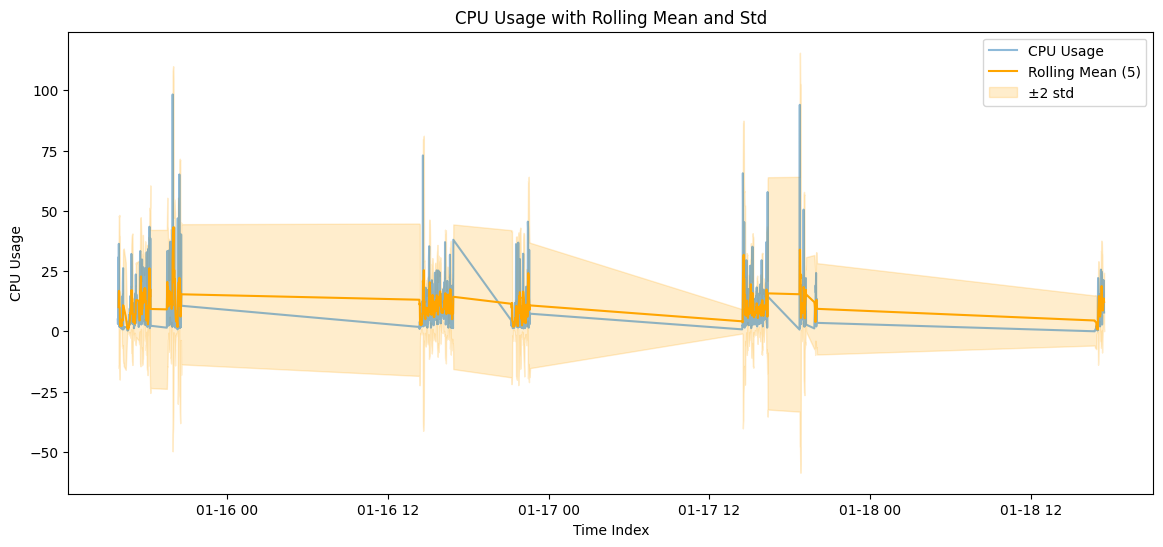

In [52]:
plt.figure(figsize=(14,6))
plt.plot(df['cpu_usage'], label='CPU Usage', alpha=0.5)
plt.plot(df['cpu_roll_mean_5'], label='Rolling Mean (5)', color='orange')
plt.fill_between(df.index, 
                 df['cpu_roll_mean_5'] - 2*df['cpu_roll_std_5'], 
                 df['cpu_roll_mean_5'] + 2*df['cpu_roll_std_5'],
                 color='orange', alpha=0.2, label='±2 std')
plt.xlabel("Time Index")
plt.ylabel("CPU Usage")
plt.title("CPU Usage with Rolling Mean and Std")
plt.legend()
plt.show()

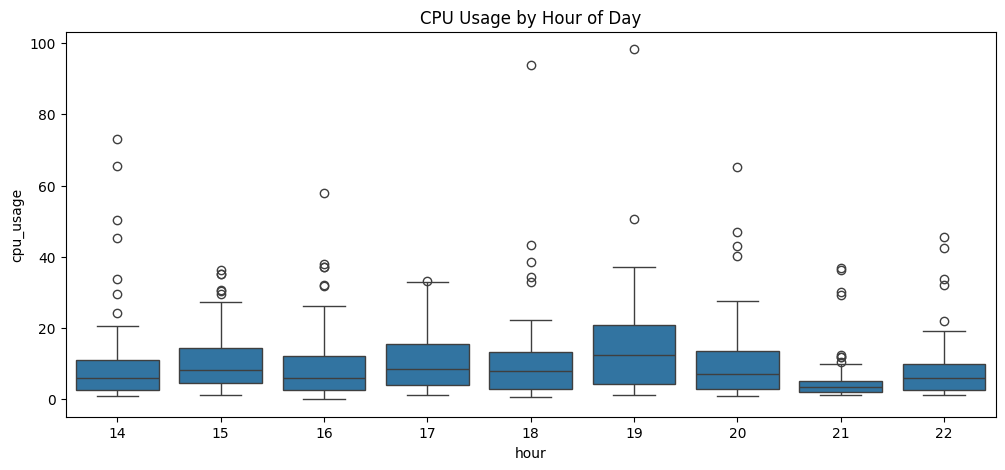

In [55]:
# CPU usage by hour
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='cpu_usage', data=df)
plt.title("CPU Usage by Hour of Day")
plt.show()

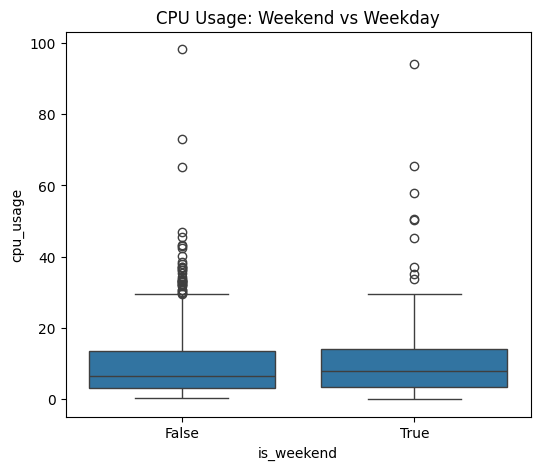

In [56]:
# cpu usage by weekend vs weekday
plt.figure(figsize=(6,5))
sns.boxplot(x='is_weekend', y='cpu_usage', data=df)
plt.title("CPU Usage: Weekend vs Weekday")
plt.show()

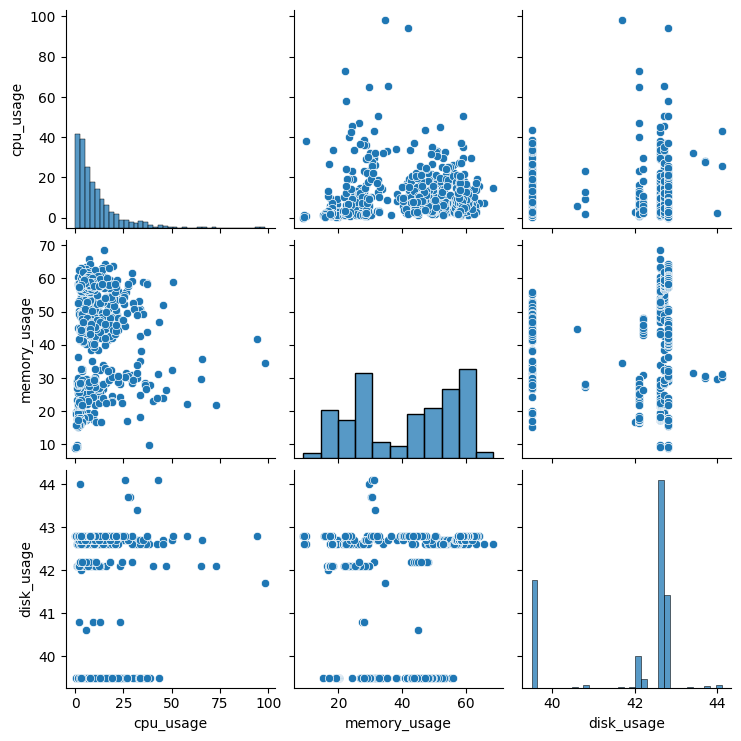

In [58]:
sns.pairplot(df[['cpu_usage', 'memory_usage', 'disk_usage']])
plt.show()

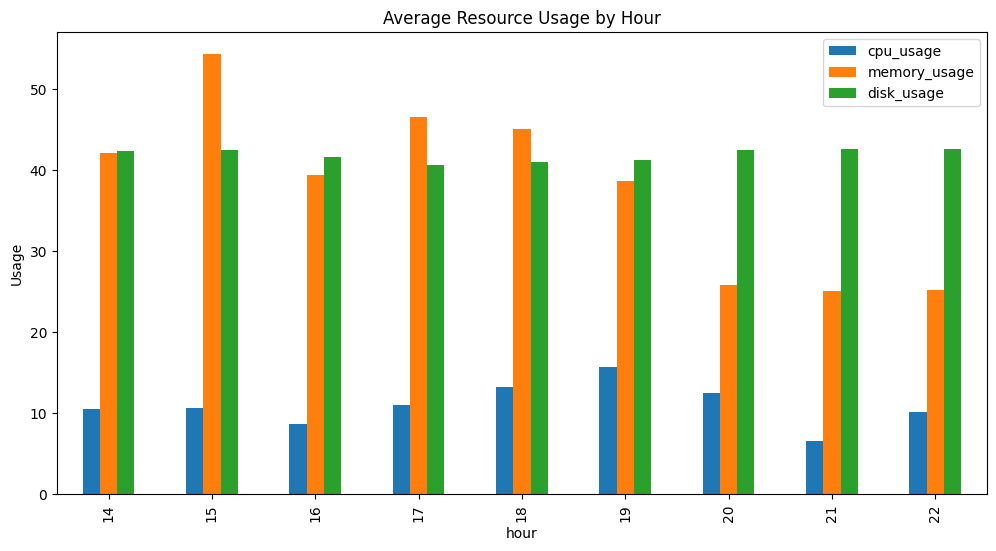

In [59]:
hourly_avg = df.groupby('hour')[['cpu_usage','memory_usage','disk_usage']].mean()
hourly_avg.plot(kind='bar', figsize=(12,6))
plt.title("Average Resource Usage by Hour")
plt.ylabel("Usage")
plt.show()

In [61]:
# saving clean dataset for machine learning model
df.to_csv("processed_dataset.csv", index = False)